# **MVAR 07) - Análisis de discriminante**

Técnica de aprendizaje máquina supervisada, que se utiliza para fines de clasificación de observaciones en grupos (o poblaciones). La clasificación se realiza mediante las funciones discriminantes, combinaciones lineales de los clasificadores originales y que se emplean como criterio para asignar un grupo.

**Referencias**
> - Notas de Clase de Leticia Gracia
> - Gema Fernández, 2024 - Fundamentos de Ciencia de Datos en R [(Book)](https://cdr-book.github.io/index.html)
> - [Scikit-Learn User Guide](https://scikit-learn.org/stable/modules/lda_qda.html)
> - [TileStats - LDA](https://www.youtube.com/watch?v=julEqA2ozcA&ab_channel=TileStats)

## **7.0) Marco teórico**

### **7.0.1) Análisis de discriminante**

El Análisis de Discriminante Lineal (LDA) y el Análisis de Discriminante Cuadrático (QLD) son clasificadores clásicos. Así como su nombre lo sugiere, utilizan una superficie de decisión lineal (recta o plano) o cuadrática (curvas o espacios curvados). Estos clasificadores son especialmente utilizados porque tienen soluciones exactas que pueden ser facilmente computadas y son, inherentemente, multi categorias.

**Descripción del conjunto de datos**  
Una de los propósitos del AD es entender qué variables son las que ayudan a segregar diferentes grupos. Por lo tanto, los pesos obtenidos al final del entrenamiento del modelo, ayudan a cuantificar la importancia de cada variable para segmentar a cada grupo.


**Reducción de dimensionalidad**  
LDA puede ser utilizado para ejecutar tareas de reducción de dimensionalidad, al proyectar los datos a un subespacio linear que consiste de las direcciones para las cuales se maximiza la separacuón entre clases. Las dimensiones resultantes son necesariamente menos que las de entrada, por lo que es una reducción de dimensiones útil, pero que solo hace sentido en un contexto multiclase.

**Desarrollo matemático**  
Existen enfoques diferentes para el AD, pero en este notebook se considera el enfoque clásico de Fischer. Como punto de partida se tienen los siguientes puntos. Así, el AD busca determinar un criterio (_regla discriminante_) que clasifique a cada individuo en uno de los $k$ grupos.

- EL AD se realiza para un conjunto de $N$ individuos para los que se conocen ciertas observaciones en un conjunto de $p$ variables continuas, de los que se conoce su grupo de pertenencia (variable vategórica $Y$). Es necesario que $p \leq N-2$

- Un conjunto de $k$ grupos ($k \geq 2$) con al menos dos individuos en cada uno.

Se asume la distribución normal multivariada del vector aleatorio $X$ dentro de cada grupo. El AD se divide de acuerdo a la matriz var-cov $\Sigma_i \; ; \; (i=1,...,k)$.

Para el caso de **Análisis Discriminante Lineal** se hace la simplificación de que cada grupo tiene la misma matriz de varianza y covarianza. En el caso contrario, para el **Análisis de Discriminante Cuadrático** se relaja esta suposición.

Sea cual sea el método. la regla discriminante se obtiene al reducir los erroes de clasificación, los cuales son evaluados probabilísticamente. Por lo que se calcula la verosimilitud de pertenencia de cada individuo a cada grupo. La verosimilitud de que el individuo $i$ pertenezca al grupo $m$ se establece como $L_m (\boldsymbol{x_i} \vert \boldsymbol{\theta_m})$. En $\boldsymbol{\theta_m}$ se recojen los parámetros de la distribución probabilística que modelan al grupo $m$. Por lo tanto, $\boldsymbol{\theta} = (\mu_i, \Sigma_i)$

Se asigna a cada individuo dentro del grupo para el cuál sea más verosimil que pertenezca. Para este desarrollo se aplica el Teorema de Bayes. De la expresión siguiente note que el método permite asignar probabilidades _a priori_, especificando conocimiento previo sobre cada grupo. Por lo tanto, el individuo $i$ se asigna al grupo $m$ si:

> $L_m(\boldsymbol{x_i} \vert \boldsymbol{\theta_m} )\pi_m = \underset{n=1,...,k}{max} \left\{ L_m(\boldsymbol{x_i} \vert \boldsymbol{\theta_m}) \pi_m \right\} $

En general. se pueden cometer dos tipos de errores: noclasificar al individuo en un gripo al que pertenece. o clasificarlo a un grupo al que no pertenece. El enfoque de maximizar la verosimilitud permite ponderar el costo de clasificar erróneamente a un individuo.

### **7.0.2) Análisis de discriminante lineal**

Para este caso se asume que las matrices var-cov de cada grupo es la misma $(\Sigma_1 = Sigma_2 = ... = \Sigma_k)$. Por lo tanto, al asumir la distribución $N_p$ (normal multivariada), lo único que distingue a cada una de las poblaciones es la media $\mu_1 \neq \mu_2 \neq ... \neq \mu_k$, por lo que el algoritmo intentará buscar el punto de partición que segregue de mejor manera a los grupos.

### **7.0.2) Análisis de discriminante cuadrático**

### **7.0.4) Shrinkage (estimación de la covarianza)**

Para estimar la matriz de varianza y covarianza $\hat{\Sigma}$, en casos para los que el número de observaciones es pequeño respecto al número de variables predictoras, se utiliza el método de _"shrinkage"_. Este permite mejorar la estimación. Ayuda a mejorar el desempeño del clasificador.

La forma en que se calcula la matriz de var-cov reducida es la siguiente, donde $T = I \; \vec{s}$, o sea que es una matriz diagonal, con elementos iguales a la varianza muestral de cada predictor, lo que asume independencia entre las variables. $S$ es la matriz var-cov muestral.

> $ \displaystyle \underset{shrinkage}{\Sigma} = \lambda T + (1-\lambda)S$

En las librerías se puede definir el parámetro manualmente o en automático. Cuando se establece como automático, se ejecuta un algoritmo que determina el valor óptimo, propuesto por Ledolf y Wolf. Note de la fórmula anterior que cuando $\lambda=0$, no se tiene ninguna reducción, por lo que se toma la matriz muestral tal cual. Por otro lado, cuando $\lambda=1$, se hace una simplificación total de la matriz.

Existen otros métodos para estimar un valor $\alpha$ óptimo, como el de _"Oracle Approximating Shrinkage"_. No siempre un método es mejor que el otro, pero se tiene experiencia empírica que cuando los datos son normales OAS arroja mejores resultados.

## **7.1) Preparar para la ejecución**

Cargar librerías utilizadas y definir base de datos

In [2]:
# General purpose
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib import colormaps as colormaps # Manually access to colormaps
from matplotlib.colors import ListedColormap
sns.set_style(style="ticks")
sns.set_palette("tab10")

# Perform discriminant analysis
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.inspection import DecisionBoundaryDisplay

# Auxiliary for various purposes
import itertools
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load dataset
from sklearn import datasets
sk_wine = datasets.load_wine()
df_data = pd.DataFrame(data=sk_wine.data, columns=sk_wine["feature_names"])
df_data["wine_type"] = pd.Series(sk_wine["target"]).map({0:"cabernet", 1:"merlot", 2:"shiraz"})
df_data.rename({"od280/od315_of_diluted_wines": "protein"}, axis=1, inplace=True)
features = df_data.columns.to_list()
features.remove("wine_type")

# Block breaker
print("="*100, "\nTarget variable distribution in the dataset:","\n")
print(df_data["wine_type"].value_counts(normalize=True).round(3))
print("="*100)

Target variable distribution in the dataset: 

wine_type
merlot      0.399
cabernet    0.331
shiraz      0.270
Name: proportion, dtype: float64


## **7.2) Análisis exploratorio de datos**

No se realiza un EDA exhaustivo, pero se muestra la correlación que existe entre las variables más importantes para fines de clasificación.

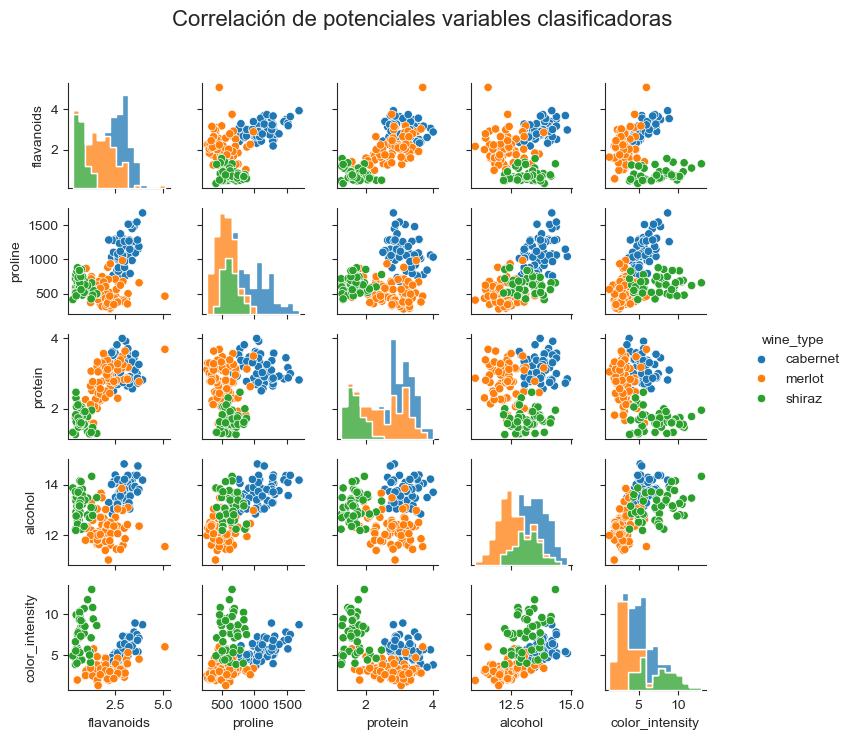

In [3]:
# Scale features using a z-score
df_temporal = (df_data[features] - df_data[features].mean()) / df_data[features].std(ddof=1)
df_temporal = pd.concat([df_temporal, df_data["wine_type"]], axis=1)

# Adjust model and run one way ANOVA to select variables of interest
temporal = {}
for variable in features:
    model_ols = ols(formula=variable+" ~ C(wine_type)", data=df_data).fit()
    temporal[variable] = sm.stats.anova_lm(model_ols, typ=2).iloc[0,3]
variables = pd.Series(temporal).sort_values(ascending=True).index.to_list()[:5]

# Slice df to preserve only variables of interest
df_temporal = df_data[variables+["wine_type"]].copy()

# Correlation plot
grid = sns.PairGrid(df_temporal, hue="wine_type", height=1.5)
grid.map_diag(sns.histplot, multiple="stack", element="step", bins=15), grid.map_offdiag(sns.scatterplot)
grid.add_legend(), grid.fig.suptitle("Correlación de potenciales variables clasificadoras",
                                     fontsize=16), plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

## **7.3 Análisis de Discriminante Lineal para 2 grupos**

### **7.3.1) Dos grupos y una variable predictora**

Es el caso más simple, pues se trata únicamente de definir un punto de corte en el plano. Para este ejercicio se intentará predecir si un vino es un Shiraz o no, conformando los dos grupos. La variable predictora será "flavanoids".

La regla de decisión para definir si un elemento pertenece a un grupo o no es la siguiente:

> $D = w_0 + w_1 x_1 \quad ; \quad$ _con punto de corte en 0_ 

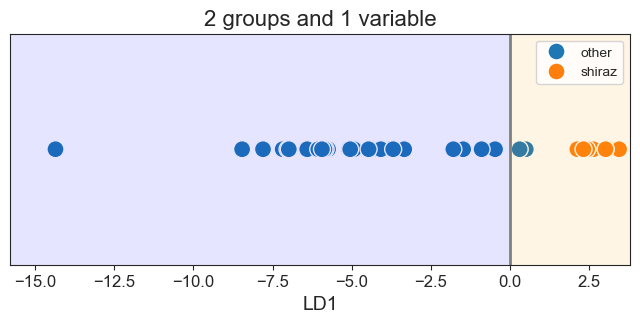

In [4]:
# Define matrices to run LDA
X = df_data[["flavanoids"]]
y = np.where(df_data["wine_type"]=="shiraz", "shiraz", "other")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=314159)

# Run model
model_lda = LDA(n_components=1, solver="eigen").fit(X_train, y_train)

# Variables for plotting
x = X_test.values.flatten() * model_lda.coef_[0][0] + model_lda.intercept_
y = [0]*X_test.shape[0]

# Plot results
plt.figure(figsize=(8,3))
sns.scatterplot(x=x, y=y, hue=y_test, s=150)
plt.axvline(0, linewidth=2, color="gray")
plt.fill_between([-20,0], -1, 1, color="blue", alpha=0.10)
plt.fill_between([0,20], -1, 1, color="orange", alpha=0.10)
plt.title("2 groups and 1 variable", fontsize=16)
plt.xlim(x.min()*1.1, x.max()*1.1), plt.ylim(-0.5, 0.5), plt.xlabel("LD1", fontsize=14), plt.xticks(fontsize=12), plt.yticks([])
plt.show()

### **7.3.2) 2 grupos y 2 variables clasificadoras**

Es un caso particular, donde se puede transitar sin dificultades entre el espacio original y el proyectado.

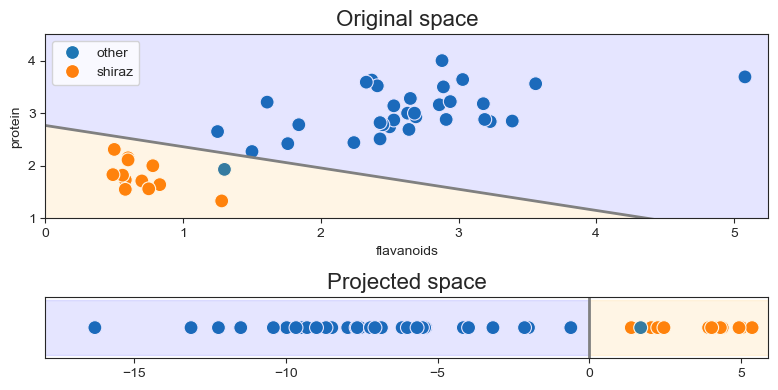

In [5]:
# Define matrices to run LDA
X = df_data[["flavanoids", "protein"]]
y = np.where(df_data["wine_type"]=="shiraz", "shiraz", "other")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=314159)

# Run model
model_lda = LDA(n_components=1, solver="eigen").fit(X_train, y_train)
# Data needed to plot results in original space
w0 = model_lda.intercept_
w1, w2 = model_lda.coef_[0]
x1 = np.linspace(-10,10,100)
x2 = -1/w2 * (x1*w1 + w0)

# Prepare gridplots
fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])  # 2 rows, with the first row being twice the height

# Plot in original space
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x1, x2, linewidth=2, color="gray")
sns.scatterplot(x=X_test.iloc[:,0], y=X_test.iloc[:,1], hue=y_test, s=100, ax=ax1)
ax1.set_title("Original space", fontsize=16), ax1.set_xlim(0,5.25), ax1.set_ylim(1,4.5)
ax1.fill_between(x1, x2, 0, color="orange", alpha=0.10), ax1.fill_between(x1, x2, 10, color="blue", alpha=0.10)

# Data needed to plot results in projected space
ax2 = fig.add_subplot(gs[1, 0])
x = (X_test.values @ model_lda.coef_.T).flatten() + model_lda.intercept_
y = [0]*X_test.shape[0]

# Plot in projected space
sns.scatterplot(x=x, y=y, hue=y_test, ax=ax2, legend=False, s=100), ax2.axvline(0, linewidth=2, color="gray")
plt.fill_between([-100,0], -1, 1, color="blue", alpha=0.10)
plt.fill_between([0,100], -1, 1, color="orange", alpha=0.10)
ax2.set_yticks([]), ax2.set_xlim([x.min()*1.1, x.max()*1.1])
ax2.set_title("Projected space", fontsize=16)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

### **7.3.2) 2 grupos y p variables clasificadoras**

Representa el siguiente paso en cuestión de complejidad. Se utiliza la función discriminante de Fischer que asigna al elemento i-ésimo una puntuación discriminante.

> $D_i = w_1x_{i,1} +...+ w_px_{i,p}$

Se establece un punto de corte de acuerdo con la siguiente expresión, que es una ponderación de los puntos de los puntajes de cada grupo:

> $C=\dfrac{n_I \bar{D}_I + n_{II} \bar{D}_{II}}{N}$
>
> _donde_ $\bar{D}_j$ _es el puntaje discriminante del centroide del grupo j_

Observe que es posible transitar entre el espacio original y el proyectado en un plano 2D, como el anterior, sin embargo esto implicaría que el resto de las variables se mantuvieran constantes.

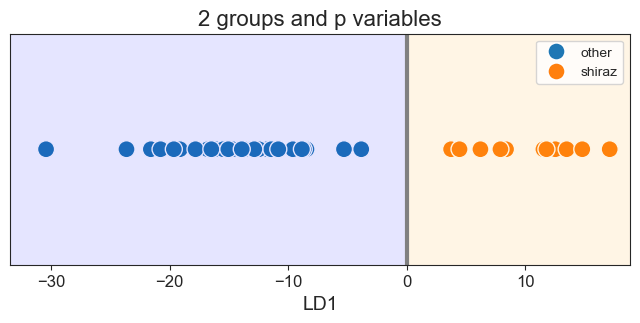

In [6]:
# Define matrices to run LDA
X = df_data[["flavanoids", "protein", "color_intensity"]]
y = np.where(df_data["wine_type"]=="shiraz", "shiraz", "other")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=314159)

# Run model
model_lda = LDA(n_components=1, solver="eigen").fit(X_train, y_train)

# Variables for plotting
x = (X_test.values @ model_lda.coef_.T).flatten() + model_lda.intercept_[0]
y = [0]*X_test.shape[0]

# Plot results
plt.figure(figsize=(8,3))
sns.scatterplot(x=x, y=y, hue=y_test, s=150)
plt.axvline(0, linewidth=3, color="gray")
plt.fill_between([-100,0], -1, 1, color="blue", alpha=0.10)
plt.fill_between([0,100], -1, 1, color="orange", alpha=0.10)
plt.title("2 groups and p variables", fontsize=16)
plt.xlim(x.min()*1.1, x.max()*1.1), plt.ylim(-0.5, 0.5), plt.xlabel("LD1", fontsize=14), plt.xticks(fontsize=12), plt.yticks([])
plt.show()

## **7.4) Análisis de Discriminante Lineal para k grupos**

En caso de existir más de dos grupos, se sigue la misma idea utulizada para dos grupos: se debe obtener un número de funcones discriminantes de Fisher suficiente para separa lo más posible los $k$ grupos. El número de funciones descriminante es $T$ tal que:

> $T=min(k-1, p)$

Cada una de las $T$ funciones discriminantes es una combinación lineal de las $p$ variables clasificadoras:

> $D_t = w_{t1}x_1 + w_{t2}x_2 + ... + w_{tp}x_p \quad ; \quad t=1,...,T$

Donde se exige que el coeficiente de correlación lineal entre cada dos funciones discriminantes distintas sea nulo (independientes).

### **7.4.1) LDA para k grupos y 1 variable**

Para este caso la regla de decisión es asignar la clase con el mayor puntaje discriminante. Note que esto es equivalente a seleccionar la clase para la cuál sea mayor la probabilidad de pertenecer.

Suponga que se calcula para 3 clases:

> $D_1 = \beta_1 + w_1 x + w_2 x + w_3 x$  
> $D_2 = \beta_2 + w_1 x + w_2 x + w_3 x$  
> $D_3 = \beta_3 + w_1 x + w_2 x + w_3 x$

Por lo tanto, el rango de $x$ para el cual la función discriminante es mayor en la clase 1, asociado a $D_1$ es:

> $D_1 > D_2 \quad$ _a la vez que_ $\quad D_1 > D_3$

Se pueden obtener las fornteras de decisión mediante la siguiente expresión:  
> $D_1 - D_2 = 0$
>   
> $x = \dfrac{\beta_2 - \beta_1}{w_1 - w_2} $

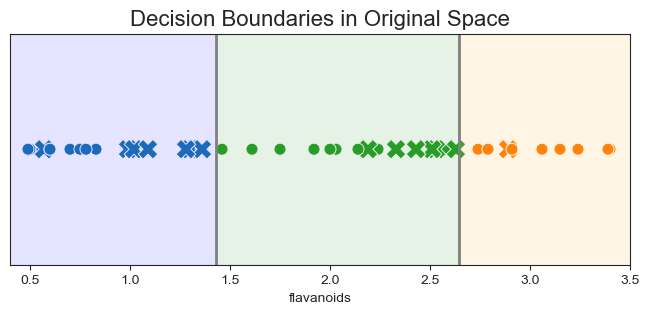

In [7]:
# Define matrices to run LDA
X = df_data[["flavanoids"]]
y = df_data["wine_type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=314159)

# Run model
model_lda = LDA(n_components=1, solver="eigen").fit(X_train, y_train)

# Used for plotting
x = X_test["flavanoids"]
y = [0] * X_test.shape[0]

# Extract weights and intercepts for the discriminant functions
b = model_lda.intercept_
w = model_lda.coef_.flatten()
lim_1 = (b[2] - b[1])/(w[1] - w[2])
lim_2 = (b[1] - b[0])/(w[0] - w[1])

# Plot the decision boundaries and wether the prediction is right or not
plt.figure(figsize=(8,3))
sns.scatterplot(x=x, y=y, hue=model_lda.predict(X_test), s=150, legend=False,
                style = (y_test == model_lda.predict(X_test)), markers={True: "o", False:"X"},
                size = (y_test == model_lda.predict(X_test)), sizes={True:75, False:200})
plt.axvline(lim_1, c="gray", linewidth=2), plt.axvline(lim_2, c="gray", linewidth=2)
plt.fill_between([-100,lim_1], -0.1, 0.1, color="blue", alpha=0.10)
plt.fill_between([lim_1,lim_2], -0.1, 0.1, color="green", alpha=0.10)
plt.fill_between([lim_2,100], -0.1, 0.1, color="orange", alpha=0.10)
plt.xlim([0.4, 3.5]), plt.ylim([-0.1, 0.1]), plt.yticks([]), plt.title("Decision Boundaries in Original Space", fontsize=16)
plt.show()

### **7.4.2) LDA para k grupos y p variables**

Para este ejercicio recuerde que el número de máximo de dimensiones para las cuales se proyecta es $min(p, k-1)$, por lo que las gráficas de dispersión en un plano $2x2$ cobran más sentido para cuando el ejercicio es de 2 variables predictoras. La proyección y la definición de las fronteras de decisión se realizan con paqueterías, debido a que definir la geometría de las áreas constituye otro problema que no es de interés por el momento.

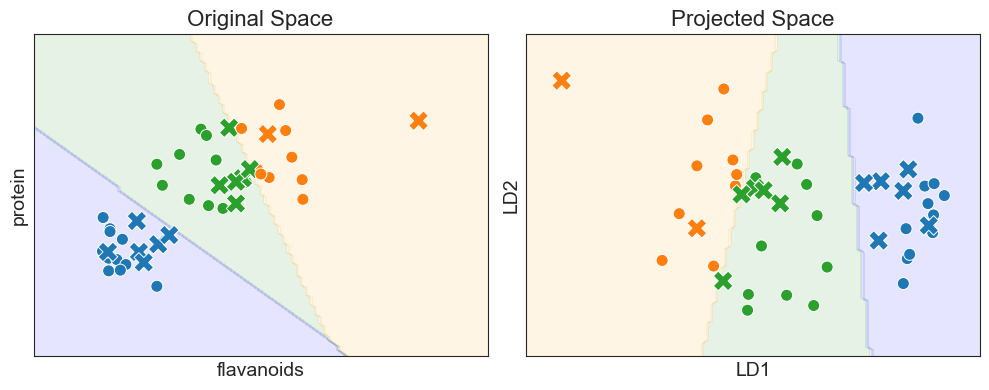

In [32]:
# Define matrices to run LDA
X = df_data[["flavanoids", "protein"]]
y = df_data["wine_type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=314159)

# Run model on the original data
model_lda = LDA(n_components=2, solver="eigen").fit(X_train, y_train)

# Prepare for plotting
custom_cmap = ListedColormap(["orange", "green", "blue"])
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,4))

# Plot decision boundaries for the original space
DecisionBoundaryDisplay.from_estimator(model_lda, X_test, response_method="predict", cmap=custom_cmap, alpha=0.1, ax=ax1,)

# Plot the scatterplot for data in the original space
df_temporal = X_test.copy()
df_temporal["predicted"] = model_lda.predict(X_test)
df_temporal["correct"] = df_temporal["predicted"].values == y_test.values
sns.scatterplot(x="flavanoids", y="protein", data=df_temporal, hue="predicted", ax=ax1, legend=False, style="correct",
                markers={True:"o", False:"X"}, size="correct", sizes={True:75, False:200})
ax1.set_xticks([]), ax1.set_yticks([])
ax1.set_xlabel(df_temporal.columns[0], fontsize=14), ax1.set_ylabel(df_temporal.columns[1], fontsize=14)
ax1.set_title("Original Space", fontsize=16)



# Run model on the projected space (it's a re-run)
X_lda_train = pd.DataFrame(model_lda.transform(X_train), columns=["LD1", "LD2"])
X_lda_test = pd.DataFrame(model_lda.transform(X_test),   columns=["LD1", "LD2"])
model_lda_2 = LDA(n_components=2, solver="eigen").fit(X_lda_train, y_train)

# Plot the decision boundary on the projected space
DecisionBoundaryDisplay.from_estimator(model_lda_2, X_lda_test, response_method="predict", cmap=custom_cmap, alpha=0.1, ax=ax2)

# Scatterplot of observations in projectd space
df_temporal = X_lda_test.copy()
df_temporal["predicted"] = model_lda_2.predict(X_lda_test)
df_temporal["correct"] = df_temporal["predicted"].values == y_test.values
sns.scatterplot(x="LD1", y="LD2", data=df_temporal, hue="predicted", ax=ax2, legend=False, style="correct",
                markers={True:"o", False:"X"}, size="correct", sizes={True:75, False:200})
ax2.set_xticks([]), ax2.set_yticks([])
ax2.set_xlabel(df_temporal.columns[0], fontsize=14), ax2.set_ylabel(df_temporal.columns[1], fontsize=14)
ax2.set_title("Projected Space", fontsize=16)



# Show plot
plt.tight_layout()
plt.show()

## **7.5)Análisis de Discriminante Cuadrático**

En el LDA se asume que las variables predictoras tienen una matriz de varianza y covarianza idénticas ($Sigma$). Al relajar esta suposición y permitiendo que cada grupo tenga su propia matriz de varianzas y covarianzas $\Siigma_j$, se constituye el Análisis de Discriminante Cuadrático.

Como consecuencia de lo anterior, las fronteras de decisión pueden curvarse y no ser precisamente rectas o planos.

### **7.5.1) QDA para k grupos y 2 variables**

Se realaiza este caso específico para mostrar las fronteras de decisión en su espacio original. Observe la curvatura de las fronteras.

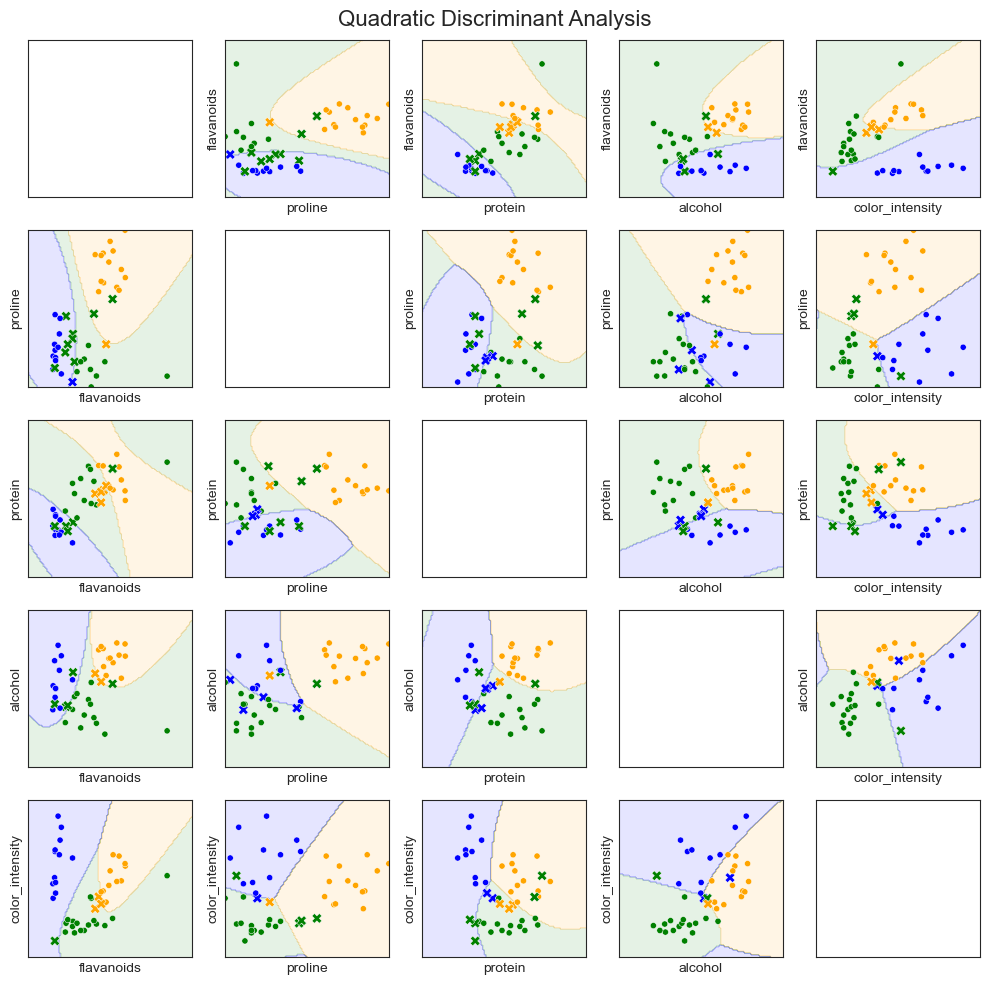

In [80]:
# Define plotting grid
fig, axes = plt.subplots(5,5, figsize=(10,10))

# Iterate over every pair of variables
for i in range(5):
    for j in range(5):
        var_1, var_2 = variables[i], variables[j]

        # When the variables are different, run the QDA, test it and plot the decision boundaries
        if var_1 != var_2: 
            X_train, X_test, y_train, y_test = train_test_split(df_data[[var_2, var_1]], y, test_size=0.25, stratify=y, random_state=314159)
            model_qda = QDA().fit(X_train, y_train)
            correct = model_qda.predict(X_test)==y_test
            DecisionBoundaryDisplay.from_estimator(model_qda, X_test, response_method="predict", cmap=custom_cmap, alpha=0.1, ax=axes[i, j])
            sns.scatterplot(x=var_2, y=var_1, hue=y_test, palette={"cabernet":"orange", "merlot":"green", "shiraz":"blue"},
                            style = correct, markers = {True:"o", False:"X"},
                            size=correct, sizes={True:20, False:50},
                            ax=axes[i, j], data=X_test, legend=False)
            axes[i, j].set_xticks([]), axes[i, j].set_yticks([])
        
        # Case when the two variables are the same. Due to collinearity, ommit the QDA.
        else:
            axes[i, j].set_xticks([]), axes[i, j].set_yticks([])
            pass

# Plot the figure
plt.suptitle("Quadratic Discriminant Analysis", fontsize=16)
plt.tight_layout()
plt.show()

### **7.5.2) QDA para k grupos y p variables**

Con la finalidad de obtener la máxima capacidad predictiva posible, en este ejercicio se toman todas las 5 variables de interés.

In [106]:
# Used to store the number of misscalsification for the model
mistakes = []

# Generate all combinations of lengths 1 to n
combinations = []
for r in range(1, len(variables) + 1):
    combinations += list(itertools.combinations(variables, r))

# Print all combinations
for combination in combinations:
    
    # Define matrices to run LDA
    X = df_data[list(combination)]
    y = df_data["wine_type"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=314159)
    
    # Run model on the original data
    model_qda = QDA().fit(X_train, y_train)

    # Count missclasifications
    mistakes += [(~(model_qda.predict(X_test)==y_test)).sum()]


The combination of variables with the lowest number of mistakes (2) is: 
 ('flavanoids', 'alcohol', 'color_intensity') 


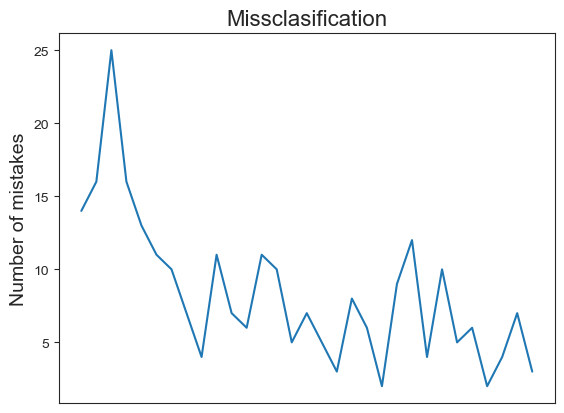

In [136]:
print("="*100+"\n"+"The combination of variables with the lowest number of mistakes ({:.0f}) is:".format(min(mistakes)) ,
     "\n", combinations[mistakes.index(min(mistakes))], "\n"+"="*100)
plt.plot(mistakes)
plt.title("Missclasification", fontsize=16), plt.ylabel("Number of mistakes", fontsize=14), plt.xticks([])
plt.show()